#### Поиск гиперпараметров и итоговый отчет:
1) Повторный запуск 5 лучших алгоритмов с параметрами по умолчанию (mode=MODE_DEFAULT)
2) Запуск Optuna для этих алгоритмов и вывод в сводной таблице информации по найденным гиперпараметрам (mode=MODE_OPTUNA)
3) Запуск алгоритмов на найденным лучших параметрах и вывод сводной таблицы (mode=MODE_BEST)
4) Сведение всех результатов (с дефолтными и лучшими параметрами) в единую таблицу
5) Отдельный вывод отчета победителя. В нашем случае это оказался дефолтный случайный лес с коэффициентом детерминации 0.854332. Выводим график сравнения пресказанных и истинных значений целевого столюца на основании отложенных в самом начале 20% чистых (не участвующих в обучении) данных. Если бы победителем оказался алгоритм с лучшими гиперпараметрами, то в отчет еще выводились бы графики optuna: plot_optimization_history, plot_param_importances, plot_contour, plot_parallel_coordinate

In [1]:
import warnings

from scipy.linalg import LinAlgWarning

from private.utils import load_reduced_bitcoin_data, memory_check
from public.models import (
    CAT_BST,
    LGBM,
    MODE_ALL,
    MODE_BEST,
    MODE_DEFAULT,
    MODE_OPTUNA,
    RAN_FOR,
    XBT_SL,
    XGB,
    RegressionProcessor,
)

with memory_check(), warnings.catch_warnings():
    warnings.simplefilter("ignore", category=LinAlgWarning)

    df = load_reduced_bitcoin_data()
    processor = RegressionProcessor(df, "target_return")   
    config = {
        RAN_FOR : {},
        LGBM : {},
        XGB : {},
        XBT_SL : {},
        CAT_BST : {}
    }
    processor.calculate(config, mode=MODE_DEFAULT)
    processor.summary_table(config.keys(), mode=MODE_DEFAULT)

regression took 4.505 seconds
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2990
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 17
[LightGBM] [Info] Start training from score 0.013808
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2992
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 17
[LightGBM] [Info] Start training from score 0.015819
[LightGBM] [Warning] Found whitespace in feature_names, replace 

,R² (Coefficient of Determination),MSE (Mean Squared Error),RMSE (Root Mean Squared Error),MAE (Mean Absolute Error),MAPE (Mean Absolute Percentage Error)
extreme_gradient_boosting (sklearn),0.854332,0.001935,0.043990,0.031464,1.511043
random_forest,0.754648,0.003259,0.057092,0.041080,1.747909
light_gradient_boosting_machine,0.751634,0.003299,0.057441,0.042937,1.939509
categorical_boosting,0.744629,0.003393,0.058246,0.043790,1.879459
extreme_gradient_boosting,0.732613,0.003552,0.059600,0.042858,1.893990


Memory Increased by: 163.64 MB


In [2]:
processor.calculate(config, mode=MODE_OPTUNA)
processor.summary_table(config, mode=MODE_OPTUNA)

  0%|          | 0/50 [00:00<?, ?it/s]

optuna_optimize took 6.565 seconds
optuna_optimize took 7.863 seconds
optuna_optimize took 9.120 seconds
optuna_optimize took 9.377 seconds
optuna_optimize took 9.559 seconds
optuna_optimize took 12.755 seconds
optuna_optimize took 13.245 seconds
optuna_optimize took 13.671 seconds
optuna_optimize took 7.235 seconds
optuna_optimize took 14.463 seconds
optuna_optimize took 17.159 seconds
optuna_optimize took 8.733 seconds
optuna_optimize took 18.380 seconds
optuna_optimize took 9.599 seconds
optuna_optimize took 11.487 seconds
optuna_optimize took 21.176 seconds
optuna_optimize took 5.200 seconds
optuna_optimize took 10.304 seconds
optuna_optimize took 5.107 seconds
optuna_optimize took 4.902 seconds
optuna_optimize took 5.836 seconds
optuna_optimize took 15.641 seconds
optuna_optimize took 5.928 seconds
optuna_optimize took 12.593 seconds
optuna_optimize took 12.349 seconds
optuna_optimize took 5.784 seconds
optuna_optimize took 4.581 seconds
optuna_optimize took 4.082 seconds
optuna_o

  0%|          | 0/50 [00:00<?, ?it/s]

optuna_optimize took 1.882 seconds
optuna_optimize took 2.996 seconds
optuna_optimize took 4.357 seconds
optuna_optimize took 5.587 seconds
optuna_optimize took 3.027 seconds
optuna_optimize took 6.397 seconds
optuna_optimize took 6.898 seconds
optuna_optimize took 6.891 seconds
optuna_optimize took 6.957 seconds
optuna_optimize took 7.516 seconds
optuna_optimize took 2.027 seconds
optuna_optimize took 1.469 seconds
optuna_optimize took 2.532 seconds
optuna_optimize took 5.236 seconds
optuna_optimize took 2.904 seconds
optuna_optimize took 2.321 seconds
optuna_optimize took 10.907 seconds
optuna_optimize took 4.190 seconds
optuna_optimize took 5.439 seconds
optuna_optimize took 12.118 seconds
optuna_optimize took 12.367 seconds
optuna_optimize took 10.832 seconds
optuna_optimize took 7.344 seconds
optuna_optimize took 8.210 seconds
optuna_optimize took 7.876 seconds
optuna_optimize took 11.938 seconds
optuna_optimize took 11.774 seconds
optuna_optimize took 11.158 seconds
optuna_optimi

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

optuna_optimize took 2.878 seconds
optuna_optimize took 3.232 seconds
optuna_optimize took 3.413 seconds
optuna_optimize took 4.759 seconds
optuna_optimize took 4.594 seconds
optuna_optimize took 5.674 seconds
optuna_optimize took 6.838 seconds
optuna_optimize took 7.272 seconds
optuna_optimize took 7.179 seconds
optuna_optimize took 9.613 seconds
optuna_optimize took 3.295 seconds
optuna_optimize took 3.775 seconds
optuna_optimize took 11.061 seconds
optuna_optimize took 8.656 seconds
optuna_optimize took 12.096 seconds
optuna_optimize took 5.308 seconds
optuna_optimize took 2.494 seconds
optuna_optimize took 9.597 seconds
optuna_optimize took 11.599 seconds
optuna_optimize took 11.941 seconds
optuna_optimize took 5.469 seconds
optuna_optimize took 12.155 seconds
optuna_optimize took 11.002 seconds
optuna_optimize took 6.396 seconds
optuna_optimize took 6.875 seconds
optuna_optimize took 6.484 seconds
optuna_optimize took 6.695 seconds
optuna_optimize took 8.738 seconds
optuna_optimiz

  0%|          | 0/50 [00:00<?, ?it/s]

Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]
Training on fold [0/5]

bestTest = 0.7105837927
bestIteration = 661

Training on fold [1/5]

bestTest = 0.7460045988
bestIteration = 522

Training on fold [1/5]

bestTest = 0.7656790163
bestIteration = 375

Training on fold [1/5]

bestTest = 0.7211830065
bestIteration = 309

Training on fold [1/5]

bestTest = 0.7506321559
bestIteration = 187

Training on fold [1/5]

bestTest = 0.6646572711
bestIteration = 653

Training on fold [2/5]

bestTest = 0.6839681274
bestIteration = 541

Training on fold [2/5]

bestTest = 0.6653386932
bestIteration = 310

Training on fold [2/5]

bestTest = 0.7557037622
bestIteration = 407

Training on fold [1/5]

bestTest = 0.7453196161
bestIteration = 404

Training on fold [1/5]

bestTest = 0.6676828375
bestItera

,R²,Best params
random_forest,0.7381,"{'n_estimators': 112, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 1.0}"
light_gradient_boosting_machine,0.7613,"{'n_estimators': 264, 'learning_rate': 0.07748547080676865, 'num_leaves': 54}"
extreme_gradient_boosting,0.7768,"{'n_estimators': 219, 'max_depth': 10, 'learning_rate': 0.20706014469818196, 'subsample': 0.942875682602226, 'colsample_bytree': 0.8297858519146943}"
extreme_gradient_boosting (sklearn),0.8402,"{'n_estimators': 208, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.7618714105768561}"
categorical_boosting,0.7779,"{'iterations': 933, 'learning_rate': 0.04090821781676071, 'depth': 7, 'l2_leaf_reg': 0.08932125883827294}"


In [3]:
processor.calculate(config, mode=MODE_BEST)
processor.summary_table(config, mode=MODE_BEST)

regression took 4.768 seconds
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2990
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 17
[LightGBM] [Info] Start training from score 0.013808
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

,R² (Coefficient of Determination),MSE (Mean Squared Error),RMSE (Root Mean Squared Error),MAE (Mean Absolute Error),MAPE (Mean Absolute Percentage Error)
extreme_gradient_boosting (sklearn),0.843510,0.002079,0.045595,0.032831,1.425924
light_gradient_boosting_machine,0.785618,0.002848,0.053367,0.039169,1.772619
extreme_gradient_boosting,0.782701,0.002887,0.053729,0.038977,1.730564
categorical_boosting,0.780699,0.002913,0.053975,0.039751,1.603502
random_forest,0.755992,0.003242,0.056935,0.040938,1.632987


In [4]:
champion_title = processor.summary_table(config, mode=MODE_ALL)

,R² (Coefficient of Determination),MSE (Mean Squared Error),RMSE (Root Mean Squared Error),MAE (Mean Absolute Error),MAPE (Mean Absolute Percentage Error),Best
extreme_gradient_boosting (sklearn),0.854332,0.001935,0.043990,0.031464,1.511043,False
extreme_gradient_boosting (sklearn)_tuned,0.843510,0.002079,0.045595,0.032831,1.425924,True
light_gradient_boosting_machine_tuned,0.785618,0.002848,0.053367,0.039169,1.772619,True
extreme_gradient_boosting_tuned,0.782701,0.002887,0.053729,0.038977,1.730564,True
categorical_boosting_tuned,0.780699,0.002913,0.053975,0.039751,1.603502,True
random_forest_tuned,0.755992,0.003242,0.056935,0.040938,1.632987,True
random_forest,0.754648,0.003259,0.057092,0.041080,1.747909,False
light_gradient_boosting_machine,0.751634,0.003299,0.057441,0.042937,1.939509,False
categorical_boosting,0.744629,0.003393,0.058246,0.043790,1.879459,False
extreme_gradient_boosting,0.732613,0.003552,0.059600,0.042858,1.893990,False



	extreme_gradient_boosting (sklearn)


R² (Coefficient of Determination),MSE (Mean Squared Error),RMSE (Root Mean Squared Error),MAE (Mean Absolute Error),MAPE (Mean Absolute Percentage Error)
0.854332,0.001935,0.043990,0.031464,1.511043


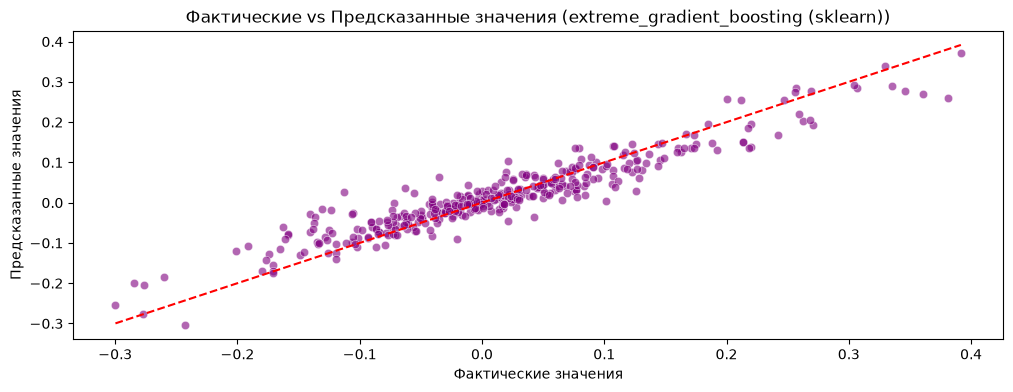

In [5]:
processor.report(title=champion_title)